In [10]:
# Cell 1: Imports and Load Data
import pickle
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

with open("ssl_features.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
y = np.array(data["labels"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Cell 2: Model Training (Logistic Regression + SVM)
log_reg = LogisticRegression(max_iter=1000)
svm_clf = SVC(probability=True)

log_reg.fit(X_train, y_train)
svm_clf.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_pred_svm = svm_clf.predict(X_test)


In [12]:
# Cell 3: Evaluation Metrics
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{name} Results:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_svm, "SVM")



Logistic Regression Results:
Accuracy:  0.8900
Precision: 0.9020
Recall:    0.8846
F1-score:  0.8932

SVM Results:
Accuracy:  0.8100
Precision: 0.8113
Recall:    0.8269
F1-score:  0.8190


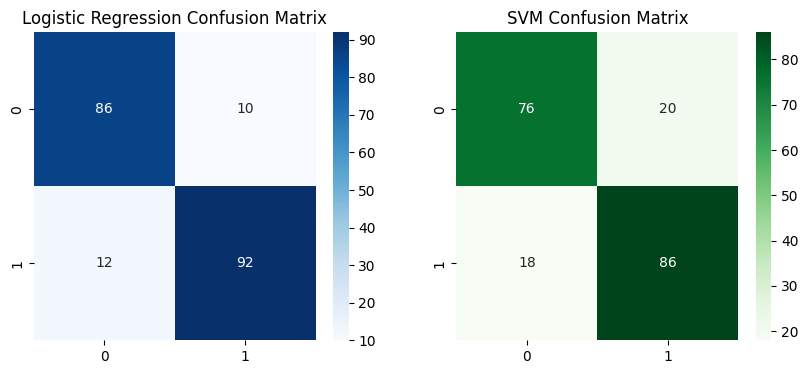

In [13]:
# Cell 4: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", ax=axes[1], cmap="Greens")
axes[1].set_title("SVM Confusion Matrix")
plt.show()


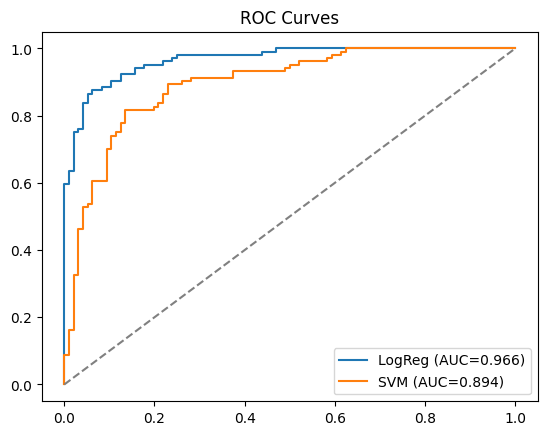

In [14]:
# Cell 5: ROC and Precision-Recall Curves
for model, name in [(log_reg, "LogReg"), (svm_clf, "SVM")]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.legend()
plt.title("ROC Curves")
plt.show()


In [15]:
# Cell 6: Cross-Validation (5-fold)
scores = cross_val_score(svm_clf, X, y, cv=5, scoring="f1")
print(f"5-Fold Cross-Validation F1-scores: {scores}")
print(f"Mean F1: {scores.mean():.4f}")


5-Fold Cross-Validation F1-scores: [0.76439791 0.82105263 0.78787879 0.80751174 0.74757282]
Mean F1: 0.7857


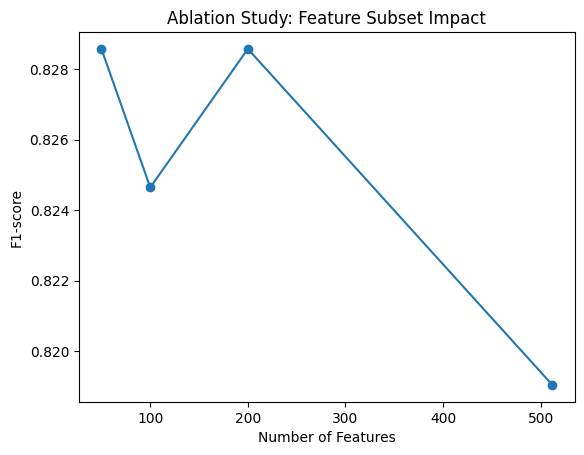

In [16]:
# Cell 7: Ablation Study (subset of features)
subset_sizes = [50, 100, 200, X.shape[1]]
f1_scores = []
for size in subset_sizes:
    X_sub = X[:, :size]
    svm = SVC()
    svm.fit(X_train[:, :size], y_train)
    y_pred = svm.predict(X_test[:, :size])
    f1_scores.append(f1_score(y_test, y_pred))
plt.plot(subset_sizes, f1_scores, marker="o")
plt.title("Ablation Study: Feature Subset Impact")
plt.xlabel("Number of Features")
plt.ylabel("F1-score")
plt.show()


In [17]:
# Cell 8: Error Analysis
misclassified = np.where(y_test != y_pred_svm)[0]
print(f"Number of Misclassified Samples: {len(misclassified)}")


Number of Misclassified Samples: 38


In [18]:
# Cell 9: Image-Level Predictions (if used for inference)
predictions = svm_clf.predict_proba(X)[:, 1]
np.savetxt("ssl_predictions.txt", predictions, fmt="%.4f")
print("Predictions saved to ssl_predictions.txt")


Predictions saved to ssl_predictions.txt
